# Neuroevolution

Today we are going to experiment with neuroevolution and see how to implement simple neuroevolutionary algorithms. We will start by implementing a simple weight evolution, then we will also try NEAT.

The evolution of only weights is very simple, we just need to implement a simple neural network with a method to set the weigths from a vector. Then we evolve an individual that contains only this vector. During the evaluation, we set the network weigths according to the individual and evaluate it. In this way, we try to implement classification on the well-known iris problem.

In [1]:
from sklearn import datasets, model_selection
import numpy as np

# read the data and divide them into training and testing sets
iris = datasets.load_iris()
train_x, test_x, train_y, test_y = model_selection.train_test_split(iris.data, iris.target)

import collections

# prepare a simple implementation of a neural network
class NeuralNetwork:

    def __init__(self, layer_sizes, activations):
        self.layer_sizes = layer_sizes
        self.layers = None

        if isinstance(activations, list):
            if len(list(activations)) != len(layer_sizes) - 1:
                raise AttributeError("Number of activations does not match number of layers")
            self.activations = list(activations)
        else:
            self.activations = [activations] * (len(layer_sizes) - 1)

        self.vectorized_net = None

    # number of network parameters
    def vectorized_size(self):
        return sum(map(lambda x: (x[0] + 1) * x[1], zip(self.layer_sizes, self.layer_sizes[1:])))

    # set the parameters based on a vector
    def set_weights(self, vectorized_net):

        if len(vectorized_net) != self.vectorized_size():
            raise AttributeError(
                f"Length of vector does not match vectorized_size: {len(vectorized_net)} != {self.vectorized_size()}")

        self.vectorized_net = vectorized_net

        self.layers = []

        sum_sizes = 0
        for (p, n) in zip(self.layer_sizes, self.layer_sizes[1:]):
            layer = vectorized_net[sum_sizes: sum_sizes + (p + 1) * n]
            self.layers.append(np.reshape(layer, shape=(p + 1, n)))
            sum_sizes += (p + 1) * n

    def eval_network(self, inputs):

        activations = inputs
        try:
            for act_func, layer in zip(self.activations, self.layers):
                activations_1 = np.append(np.array([1.0]), activations)  # add constant 1.0 for the bias term
                activations = act_func(np.dot(activations_1, layer))
        except Exception as e:
            print("Activations:", activations)
            raise e

        return activations

We use the CMA-ES algorithm for setting the weights of the neural network. CMA-ES is an evolutionary strategy that adapts the entire covariance matrix of a multinomial normal distribution. It is implemented in the deap library we have already seen and it is easy to use.

In [2]:
def relu(x):
    return np.maximum(0,x)

def linear(x):
    return x

net = NeuralNetwork([4, 5, 3], [relu, linear])
ind_size = net.vectorized_size()

def fitness(ind, X, y):
    net.set_weights(ind)
    
    acc = 0
    for xi, yi in zip(X, y):
        if np.argmax(net.eval_network(xi)) == yi:
            acc += 1
    
    return acc/len(y),
        
from deap import algorithms, creator, base, benchmarks, cma, tools

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("evaluate", fitness, X=train_x, y=train_y)

strategy = cma.Strategy(centroid=[0.0]*ind_size, sigma=0.1, lambda_=5*ind_size)
toolbox.register("generate", strategy.generate, creator.Individual)
toolbox.register("update", strategy.update)

hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

_ = algorithms.eaGenerateUpdate(toolbox, ngen=75, stats=stats, halloffame=hof)

gen	nevals	avg     	std     	min	max     
0  	215   	0.346221	0.103354	0  	0.696429
1  	215   	0.34211 	0.0996302	0  	0.696429
2  	215   	0.352492	0.0942193	0  	0.696429
3  	215   	0.35461 	0.0998963	0  	0.696429
4  	215   	0.3674  	0.0936936	0  	0.696429
5  	215   	0.38098 	0.099263 	0  	0.696429
6  	215   	0.388912	0.103951 	0  	0.75    
7  	215   	0.399252	0.116811 	0  	0.696429
8  	215   	0.383389	0.103119 	0.0982143	0.767857
9  	215   	0.40897 	0.12701  	0        	0.696429
10 	215   	0.410963	0.126574 	0.0357143	0.723214
11 	215   	0.411877	0.145432 	0        	0.696429
12 	215   	0.432101	0.146288 	0.0178571	0.848214
13 	215   	0.433638	0.155046 	0        	0.8125  
14 	215   	0.45544 	0.151941 	0.241071 	0.785714
15 	215   	0.430523	0.150665 	0        	0.696429
16 	215   	0.44186 	0.159819 	0.0178571	0.955357
17 	215   	0.480814	0.168208 	0.00892857	0.830357
18 	215   	0.484385	0.161958 	0.258929  	0.892857
19 	215   	0.493355	0.16758  	0.160714  	0.857143
20 	215   	0.484759	0.16

We will evaluate the accuracy on the testing data.

In [3]:
fitness(hof[0], test_x, test_y)

(0.8947368421052632,)

# NEAT

The NEAT algorithms is implemented in the `neat-python` library. The library has a slightly different interface than what we are used to, but it is not difficult to learn how to use it. The algorithm settings are loaded from a file, and then we just run the algorithm. Below we show an example from the `neat-python` documentation modified for iris classification.

For the visualization of the network, you will need to install the `python-graphviz` package.


 ****** Running generation 0 ****** 

Population's average fitness: 35.66000 stdev: 14.71635
Best fitness: 91.00000 - size: (3, 12) - species 1 - id 111
Average adjusted fitness: 0.392
Mean genetic distance 1.085, standard deviation 0.241
Population of 150 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0   150     91.000    0.392     0
Total extinctions: 0
Generation time: 0.161 sec

 ****** Running generation 1 ****** 

Population's average fitness: 42.28000 stdev: 16.59121
Best fitness: 91.00000 - size: (3, 12) - species 1 - id 111
Average adjusted fitness: 0.465
Mean genetic distance 1.259, standard deviation 0.292
Population of 150 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    1   150     91.000    0.465     1
Total extinctions: 0
Generation time: 0.159 sec (0.160 average)

 ****** Running gener

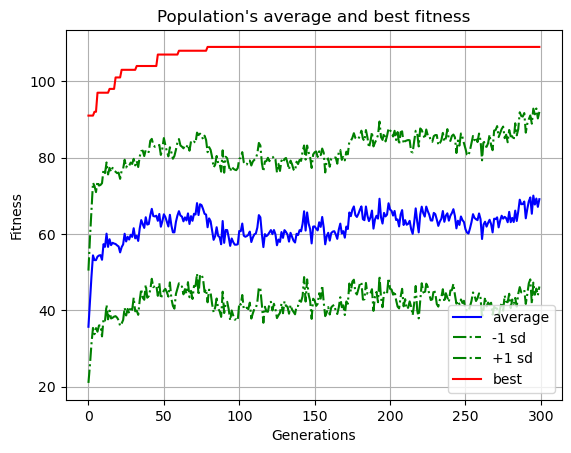

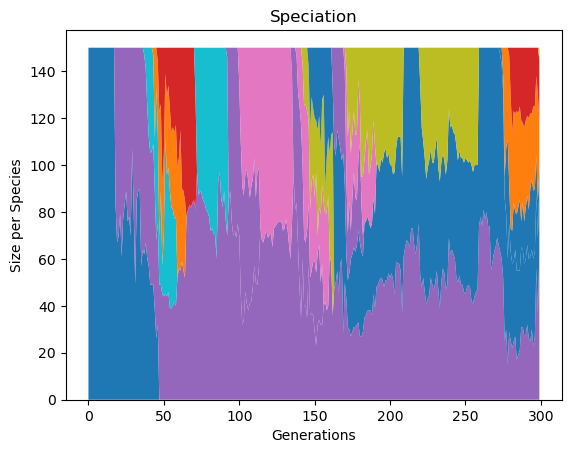

In [4]:
import os
import neat
import visualize

def eval_genomes(genomes, config):
    for genome_id, genome in genomes:
        genome.fitness = 0.0
        net = neat.nn.FeedForwardNetwork.create(genome, config)
        for x, y in zip(train_x, train_y):
            output = net.activate(x)
            genome.fitness += 1 if np.argmax(output) == y else 0


def run(config_file):
    # Load configuration.
    config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                         neat.DefaultSpeciesSet, neat.DefaultStagnation,
                         config_file)

    # Create the population, which is the top-level object for a NEAT run.
    p = neat.Population(config)

    # Add a stdout reporter to show progress in the terminal.
    p.add_reporter(neat.StdOutReporter(True))
    stats = neat.StatisticsReporter()
    p.add_reporter(stats)
    p.add_reporter(neat.Checkpointer(5))

    # Run for up to 300 generations.
    winner = p.run(eval_genomes, 300)

    # Display the winning genome.
    print('\nBest genome:\n{!s}'.format(winner))

    # Show output of the most fit genome against training data.
    print('\nOutput:')
    winner_net = neat.nn.FeedForwardNetwork.create(winner, config)
    for xi, xo in zip(train_x, train_y):
        output = winner_net.activate(xi)
        print("input {!r}, expected output {!r}, got {!r}".format(xi, xo, output))

    node_names = {-1:'x1', -2: 'x2', -3: 'x3', -4: 'x4', 0:'setosa', 1:'virginica', 2:'versicolor'}
    visualize.draw_net(config, winner, True, node_names=node_names)
    visualize.plot_stats(stats, ylog=False, view=True)
    visualize.plot_species(stats, view=True)

    p = neat.Checkpointer.restore_checkpoint('neat-checkpoint-5')
    p.run(eval_genomes, 10)


if __name__ == '__main__':
    # Determine path to configuration file. This path manipulation is
    # here so that the script will run successfully regardless of the
    # current working directory.
    config_path = os.path.join('.', 'config-feedforward')
    run(config_path)